In [432]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.pipeline import make_pipeline

In [433]:
x = 6 * np.random.rand(200, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(200, 1) # this is the target variable with some noise which uses a quadratic function

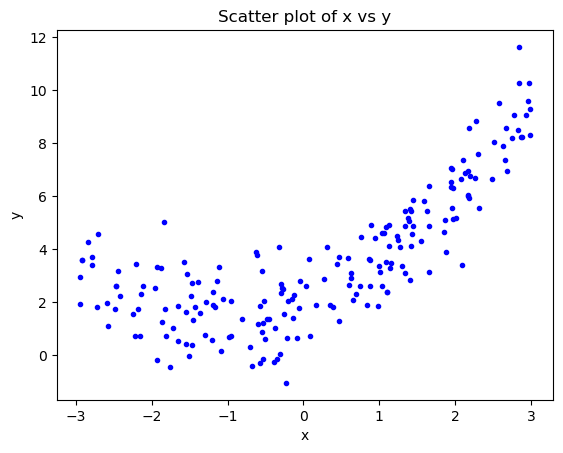

In [434]:
plt.plot(x,y,"b.")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x vs y")
plt.show()

In [435]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.4288393375631018

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_31793/1168999541.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  plt.plot(X_train, y_train,"b.", color='blue')


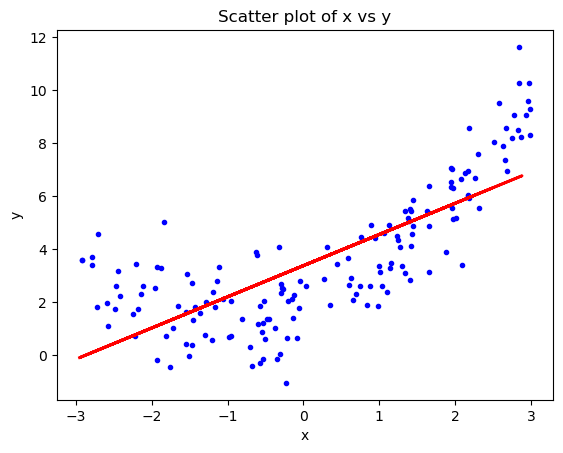

In [ ]:
plt.plot(X_train, y_train,"b.", color='blue')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x vs y for linear regression")
plt.plot(X_test,y_pred, color='red', linewidth=2)

When you see include_bias=True in something like PolynomialFeatures from scikit-learn, it’s about whether to add the bias (intercept) column to your feature matrix 
𝑋

In [437]:
# applying polynomial regression
poly = PolynomialFeatures(degree=2,include_bias=True)  # include_bias=True adds a column of ones for the intercept term
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [438]:
print(X_train[0])
print(X_train_poly[0])

[-0.50132644]
[ 1.         -0.50132644  0.2513282 ]


In [439]:
lr = LinearRegression()
lr.fit(X_train_poly,y_train)
y_pred_poly = lr.predict(X_test_poly)

In [440]:
r2_score(y_test,y_pred_poly)

0.7691609453967193

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_31793/2107727354.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  plt.plot(X_train_poly, y_train,"b.", color='blue')


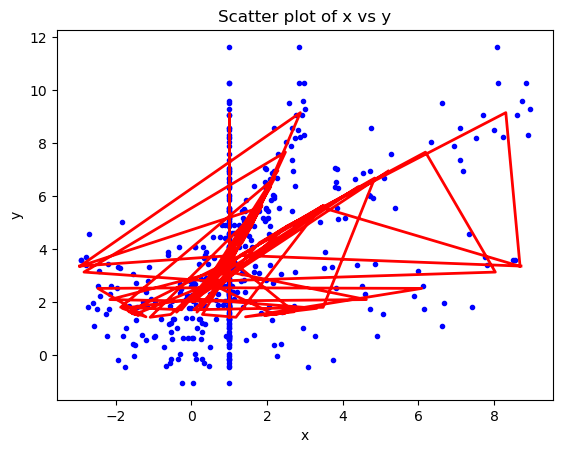

In [ ]:
plt.plot(X_train_poly, y_train,"b.", color='blue')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x vs y for polynomial regression")
plt.plot(X_test_poly, y_pred_poly, color='red', linewidth=2)

In [442]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

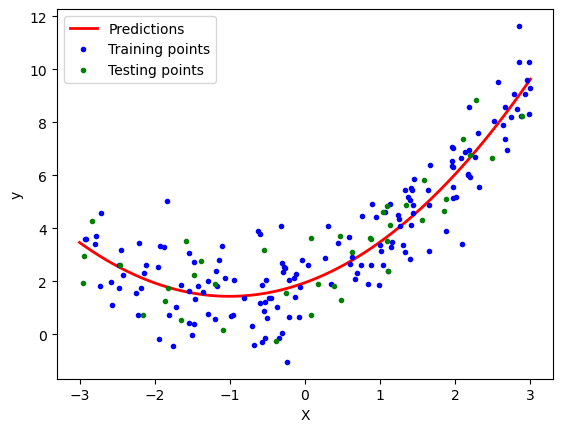

In [443]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [444]:
x.shape


(200, 1)

In [445]:
x.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [ ]:
# polynomial regression

from sklearn.pipeline import Pipeline
def polynomial_regression(degree): #you pass the degree of the polynomial to specify how high the polynomial should be
    X_new = np.linspace(-3, 3, 200).reshape(200, 1) #creates 200 evenly spaced points between -3 and 3 which reshapes it to a 2D array
    X_new_poly = poly.transform(X_new) #transforms the new X values to polynomial features
    
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()

    """
    PolynomialFeatures → generates all powers up to degree (but no bias column since LinearRegression can handle intercept).

    StandardScaler → normalizes features so that large powers (like 𝑥^5) don’t dominate.

    LinearRegression → standard ordinary least squares.
    """
    polynomial_regression = Pipeline([
    ("poly_features", polybig_features),
    ("std_scaler", std_scaler),
    ("lin_reg", lin_reg),
    ])
    """
    This Pipeline automatically:

    Expands features to polynomial terms.

    Scales them.

    Fits a linear regression.

    Benefit: Keeps transformations consistent during training & prediction
    """

    polynomial_regression.fit(x, y) # fits the data to the polynomial regression model
    y_newbig = polynomial_regression.predict(X_new) # predicts the new X values using the polynomial regression model

    plt.plot(X_new, y_newbig, "r-", linewidth=2, label="Predictions")
    plt.plot(X_train, y_train, "b.", label='Training points')

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()




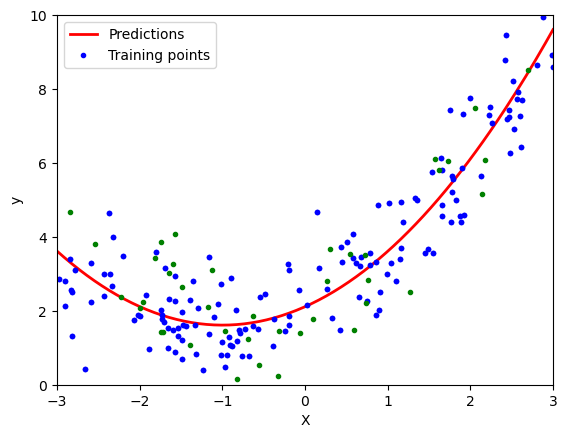

In [ ]:
polynomial_regression(2)  # you can change the degree to see how it affects the fit

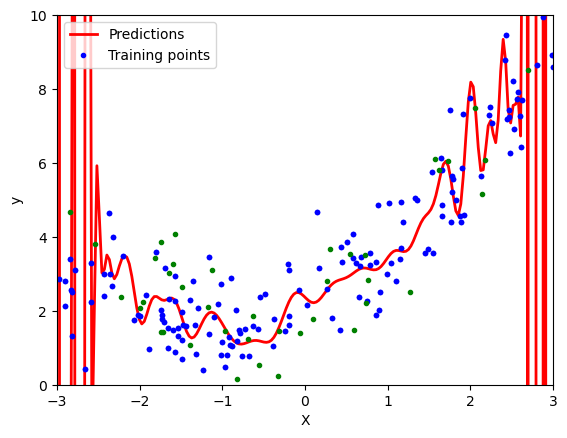

In [ ]:
polynomial_regression(290)

# Own Polynomial Regression Class

In [ ]:
import numpy as np
from itertools import combinations_with_replacement
class OwnPolynomialRegression:
    def __init__(self, degree):
        self.degree = degree
        self.coef_ = None
        self.intercept_ = None

   # using this function we expand the features into polynomial terms
    def _expand_features(self, X, degree):
        X_poly = X.copy()  # start with the original feature # makes a copy of the original feature matrix
        X_poly = X_poly.reshape(-1, 1)  # ensure X_poly is a 2D array with one column
        # Generate polynomial features up to the specified degree
        for d in range(2, degree + 1):
            X_poly = np.c_[X_poly, X[:, 0]**d]  # add x^2, x^3, ...
        print("X_poly.shape:", X_poly.shape)  # Debugging line to check the shape of X_poly
        return X_poly



    def fit(self, X, y):
        # Expand features into polynomial terms
        X_poly = self._expand_features(X, degree=self.degree)
        # Add bias term (intercept column of 1s)
        X_b = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]  # ensure X_b is a 2D array with one column for the intercept
        
        # Normal equation: theta = (X^T X)^(-1) X^T y
        theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        
        self.intercept_ = theta_best[0].reshape(-1, 1)  # ensure intercept is a 2D array with one column
        self.coef_ = theta_best[1:]

    def predict(self, X):
        # Expand features
        X_poly = self._expand_features(X, degree=self.degree)  # ensure X_poly is a 2D array with one column
        # Add bias term
        print("X_poly.shape2:", X_poly.shape)
        X_b = np.c_[np.ones((X_poly.shape[0], 1)), X_poly] # ensure X_b is a 2D array with one column for the intercept
        #print(self.intercept_.shape, self.coef_.shape)  # Debugging line to check the shapes of intercept and coef
        m = np.r_[self.intercept_, self.coef_]
        #print(m.shape)
        return np.dot(X_b, m)


In [ ]:
OwnPolynomialRegression = OwnPolynomialRegression(degree=3)
OwnPolynomialRegression.fit(X_train, y_train)
print(r2_score(y_test, OwnPolynomialRegression.predict(X_test)))


X_poly.shape: (160, 3)
X_poly.shape: (40, 3)
X_poly.shape2: (40, 3)
0.8356690810431526


In [ ]:
from sklearn.linear_model import LinearRegression
LinearRegression = LinearRegression()
LinearRegression.fit(X_train, y_train)
print(r2_score(y_test, LinearRegression.predict(X_test)))

0.6098387490771862


X_poly.shape: (40, 3)
X_poly.shape2: (40, 3)


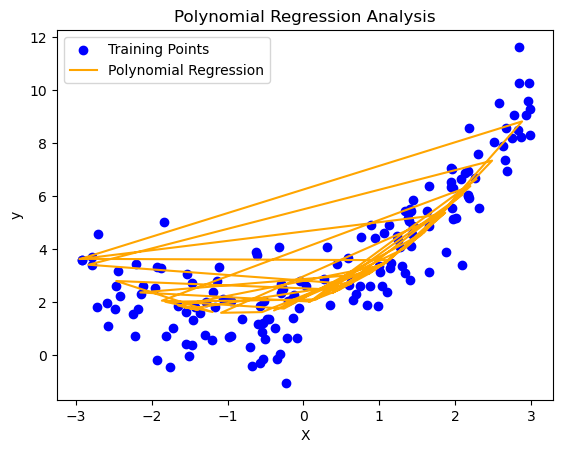

In [446]:
plt.scatter(X_train, y_train, color='blue', label='Training Points')
plt.plot(X_test, OwnPolynomialRegression.predict(X_test), color='orange', label='Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Analysis')
plt.legend()
plt.show()  